# Cycle 3 — Modelling: Player Injury Risk

**Dataset:** `data/processed/player_injuries_processed.csv`

Train and evaluate baseline models for player injury risk prediction. The target is `High_Injury` (1 = player misses 28+ days this season, 0 = misses fewer than 28 days). This is a binary classification problem with a 70/30 class imbalance.

AUC-ROC will be used a the primary metric to determine model learning due the data having a high imbalance. 

In [ ]:
import sys, os  

_here = os.getcwd()                                        
while not os.path.isdir(os.path.join(_here, 'data')):     
    _p = os.path.dirname(_here)                           
    if _p == _here: raise RuntimeError('project root not found')  
    _here = _p
if _here not in sys.path:
    sys.path.insert(0, _here)                           

from config import Paths, ensure_dirs
ensure_dirs()  


In [3]:
import pandas as pd                       
import numpy as np                        
import matplotlib.pyplot as plt           
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler    # z-score scaler
from sklearn.dummy import DummyClassifier           # majority-class baseline
from sklearn.linear_model import LogisticRegression # linear classifier
from sklearn.ensemble import RandomForestClassifier # ensemble trees
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

df = pd.read_csv(str(Paths.PLAYER_INJURIES_PROCESSED))  # preprocessed injury dataset
X = df.drop(columns=['High_Injury'])   # 17 pre-season features
y = df['High_Injury']                  # binary target: 0=low, 1=high injury burden

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify preserves 70/30 ratio
)

scaler = StandardScaler()                      # z-score scaler for LR
X_train_s = scaler.fit_transform(X_train)       # fit on train only
X_test_s  = scaler.transform(X_test)            # apply to test

spw = y_train.value_counts()[0] / y_train.value_counts()[1]  # low/high ratio for XGB/LGB

print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'High Injury rate - Train: {y_train.mean()*100:.1f}% | Test: {y_test.mean()*100:.1f}%')
print(f'scale_pos_weight: {spw:.2f}')  # <1 means High Injury is the majority class
print(f'Features ({len(X.columns)}): {list(X.columns)}')


Train: 1040 | Test: 261
High Injury rate - Train: 70.2% | Test: 70.1%
scale_pos_weight: 0.42
Features (17): ['height_cm', 'weight_kg', 'pace', 'physic', 'fifa_rating', 'age', 'cumulative_minutes_played', 'cumulative_games_played', 'minutes_per_game_prev_seasons', 'avg_days_injured_prev_seasons', 'avg_games_per_season_prev_seasons', 'bmi', 'work_rate_numeric', 'position_numeric', 'significant_injury_prev_season', 'cumulative_days_injured', 'season_days_injured_prev_season']


- Note: scale_pos_weight = 0.42 (less than 1.0) because the majority class is High Injury (70.2%), not Low Injury. XGBoost needs to upweight the minority class (Low Injury, 29.8%)
- The dataset is small: only 1,040 training rows. This limits complex model performance and could lead/explain why tuning gains will be modest

## Dummy Classifier

Always predicts the most frequent class (High Injury — 70%+ of the dataset) regardless of features.

In [4]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)  # always predict High Injury
dummy.fit(X_train_s, y_train)                                         # just counts frequencies
y_pred_d = dummy.predict(X_test_s)                                    # predicts 1 for all
y_prob_d = dummy.predict_proba(X_test_s)[:,1]                        # constant probability

print('DUMMY CLASSIFIER')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_d)*100:.2f}%  |  AUC: {roc_auc_score(y_test, y_prob_d):.4f}')
# AUC=0.5 = random guessing; accuracy ~70% from predicting majority
print(classification_report(y_test, y_pred_d, target_names=['Low Injury','High Injury']))


DUMMY CLASSIFIER
  Accuracy: 70.11%  |  AUC: 0.5000
              precision    recall  f1-score   support

  Low Injury       0.00      0.00      0.00        78
 High Injury       0.70      1.00      0.82       183

    accuracy                           0.70       261
   macro avg       0.35      0.50      0.41       261
weighted avg       0.49      0.70      0.58       261



- 70.11% accuracy from always predicting High Injury -- confirms why accuracy is misleading
- AUC 0.5 = random guessing. All real models must exceed this

## Logistic Regression

Fits a linear decision boundary on scaled features. `class_weight='balanced'` compensates for the 70/30 class split.
- Logistic Regression is particularly useful here because injury prediction may have a linear relationship with some features (e.g. age, cumulative days injured). It also produces well-calibrated probabilities.


In [5]:
lr = LogisticRegression(
    class_weight='balanced',  # up-weight low-injury class (minority)
    max_iter=1000,            # ensure convergence
    random_state=42
)
lr.fit(X_train_s, y_train)             # train on z-scored features
y_pred_lr = lr.predict(X_test_s)       # class predictions
y_prob_lr = lr.predict_proba(X_test_s)[:,1]  # injury probability (for AUC)

print('LOGISTIC REGRESSION')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_lr)*100:.2f}%  |  AUC: {roc_auc_score(y_test, y_prob_lr):.4f}')
print(classification_report(y_test, y_pred_lr, target_names=['Low Injury','High Injury']))


LOGISTIC REGRESSION
  Accuracy: 55.17%  |  AUC: 0.6220
              precision    recall  f1-score   support

  Low Injury       0.36      0.62      0.45        78
 High Injury       0.76      0.52      0.62       183

    accuracy                           0.55       261
   macro avg       0.56      0.57      0.54       261
weighted avg       0.64      0.55      0.57       261



- AUC 0.6220: best baseline model despite lowest accuracy (55.17%)
- Balanced weighting causes more Low Injury predictions, trading accuracy for better discrimination
- Low Injury recall 0.62 -- correctly identifies 62% of low-risk players
- Consistent with sports science literature: linear models perform well when injury risk has an approximately linear relationship with history metrics

## Random Forest

Trains 200 decision trees on random subsets of rows and features, then aggregates by majority vote.
- Injury risk has non-linear patterns (e.g. risk spikes at certain age + injury history combinations) that Logistic Regression may miss. Random Forest handles these interaction effects.


In [6]:
rf = RandomForestClassifier(
    n_estimators=200,        # 200 trees
    class_weight='balanced', # compensate for 70/30 imbalance
    random_state=42,
    n_jobs=-1                # parallelise
)
rf.fit(X_train_s, y_train)             # train on scaled features
y_pred_rf = rf.predict(X_test_s)
y_prob_rf = rf.predict_proba(X_test_s)[:,1]  # injury probability

print('RANDOM FOREST')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.2f}%  |  AUC: {roc_auc_score(y_test, y_prob_rf):.4f}')
print(classification_report(y_test, y_pred_rf, target_names=['Low Injury','High Injury']))


RANDOM FOREST
  Accuracy: 72.03%  |  AUC: 0.5916
              precision    recall  f1-score   support

  Low Injury       0.65      0.14      0.23        78
 High Injury       0.73      0.97      0.83       183

    accuracy                           0.72       261
   macro avg       0.69      0.55      0.53       261
weighted avg       0.70      0.72      0.65       261



- High accuracy (72.03%) but AUC only 0.5916 which is near-random discrimination
- Model is essentially predicting High Injury for almost everyone (recall 0.97)
- This shows Random Forest with default settings collapses to majority-class prediction despite balanced weighting

## XGBoost

Gradient boosting — builds trees sequentially, each correcting residual errors. Uses `scale_pos_weight` to handle class imbalance.
- XGBoost has been the most accurate model in Cycles 1 and 2. Testing it here establishes whether it carries over to injury prediction or whether the small dataset (1,301 rows) limits its advantage.


In [11]:
xgb = XGBClassifier(
    scale_pos_weight=spw,    # weight low-injury class to compensate imbalance
    random_state=42,
    eval_metric='auc',       # optimise AUC during training
    verbosity=0
)
xgb.fit(X_train_s, y_train)
y_pred_xgb = xgb.predict(X_test_s)
y_prob_xgb = xgb.predict_proba(X_test_s)[:,1]  # injury probability

print('XGBOOST')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_xgb)*100:.2f}%  |  AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}')
print(classification_report(y_test, y_pred_xgb, target_names=['Low Injury','High Injury']))


XGBOOST
  Accuracy: 65.52%  |  AUC: 0.6179
              precision    recall  f1-score   support

  Low Injury       0.41      0.36      0.38        78
 High Injury       0.74      0.78      0.76       183

    accuracy                           0.66       261
   macro avg       0.58      0.57      0.57       261
weighted avg       0.64      0.66      0.65       261



- AUC 0.6179: competitive with LR. scale_pos_weight correctly pushes XGBoost to predict Low Injury more
- Better than RF at discrimination (0.6179 vs 0.5916) but worse than LR (0.6220)

## LightGBM

Leaf-wise gradient boosting. Uses `scale_pos_weight` for class imbalance handling.
- LightGBM was the best untuned model in Cycles 1 and 2. Testing it on this much smaller dataset (1,301 vs 6,840 / 8,451 rows) will reveal whether its advantage holds at small scale.


In [8]:
lgb = LGBMClassifier(
    scale_pos_weight=spw,    # same class weight strategy as XGBoost
    n_estimators=100,        # 100 boosting rounds
    random_state=42,
    verbose=-1               # suppress output
)
lgb.fit(X_train_s, y_train)
y_pred_lgb = lgb.predict(X_test_s)
y_prob_lgb = lgb.predict_proba(X_test_s)[:,1]  # injury probability

print('LIGHTGBM')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_lgb)*100:.2f}%  |  AUC: {roc_auc_score(y_test, y_prob_lgb):.4f}')
print(classification_report(y_test, y_pred_lgb, target_names=['Low Injury','High Injury']))


LIGHTGBM
  Accuracy: 67.43%  |  AUC: 0.6355
              precision    recall  f1-score   support

  Low Injury       0.45      0.37      0.41        78
 High Injury       0.75      0.80      0.78       183

    accuracy                           0.67       261
   macro avg       0.60      0.59      0.59       261
weighted avg       0.66      0.67      0.67       261



- LightGBM achieved the highest baseline AUC (0.6355), outperforming both the linear model and the Random Forest. 

# ROC Curve Comparison

Plots AUC-ROC curves for all 5 models on the same axes.
- Despite the 70/30 imbalance being less extreme than Cycle 2's 9:1, AUC remains the right metric because it measures the model's ability to rank players by risk. 

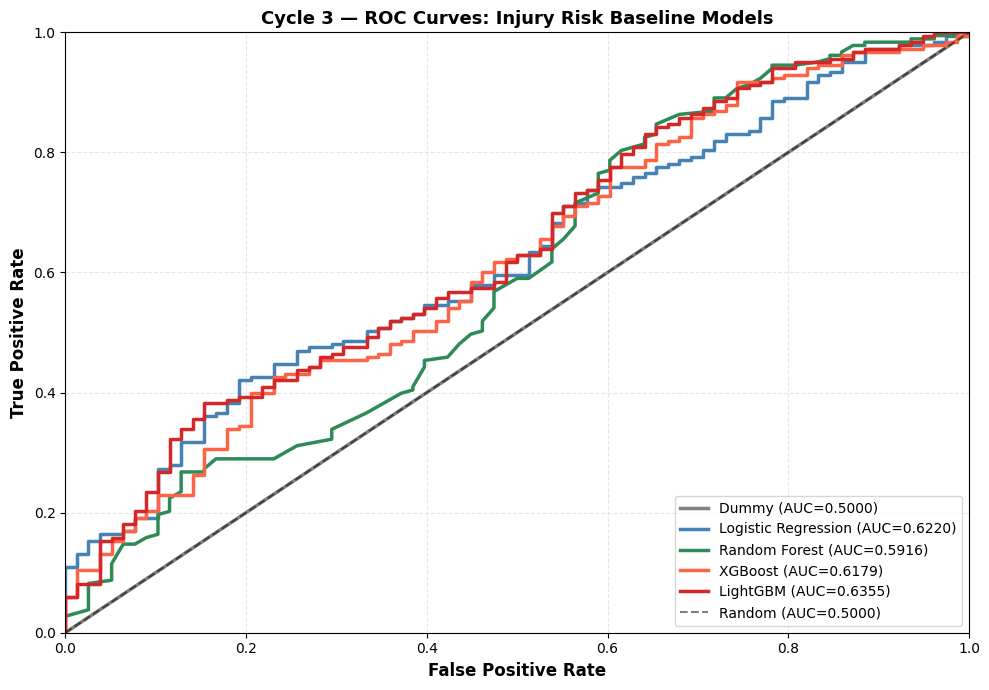

In [ ]:
os.makedirs('../../docs', exist_ok=True)  

fig, ax = plt.subplots(figsize=(10, 7))
for name, probs, color in [
    ('Dummy',               y_prob_d,   'gray'),
    ('Logistic Regression', y_prob_lr,  'steelblue'),
    ('Random Forest',       y_prob_rf,  'seagreen'),
    ('XGBoost',             y_prob_xgb, 'tomato'),
    ('LightGBM',            y_prob_lgb, '#d62728'),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)  # compute ROC curve points
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, linewidth=2.5)

ax.plot([0,1],[0,1],'k--',linewidth=1.5, alpha=0.5, label='Random (AUC=0.5000)')  # diagonal = chance
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('Cycle 3 — ROC Curves: Injury Risk Baseline Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3, linestyle='--')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig('../../docs/cycle3_roc_baseline.png', dpi=300, bbox_inches='tight')  # save for report
plt.show()


# Full Baseline Summary

Creates a ranked table of all baseline model results.
- A single table comparing Accuracy and AUC-ROC makes it immediately clear which metric matters (AUC) and which is misleading (Accuracy — all models above 70% just by predicting High Injury).


In [10]:
results = pd.DataFrame([
    {'Model': 'Dummy',               'Accuracy': accuracy_score(y_test, y_pred_d)*100,   'AUC-ROC': roc_auc_score(y_test, y_prob_d)},
    {'Model': 'Logistic Regression', 'Accuracy': accuracy_score(y_test, y_pred_lr)*100,  'AUC-ROC': roc_auc_score(y_test, y_prob_lr)},
    {'Model': 'Random Forest',       'Accuracy': accuracy_score(y_test, y_pred_rf)*100,  'AUC-ROC': roc_auc_score(y_test, y_prob_rf)},
    {'Model': 'XGBoost',             'Accuracy': accuracy_score(y_test, y_pred_xgb)*100, 'AUC-ROC': roc_auc_score(y_test, y_prob_xgb)},
    {'Model': 'LightGBM',            'Accuracy': accuracy_score(y_test, y_pred_lgb)*100, 'AUC-ROC': roc_auc_score(y_test, y_prob_lgb)},
])

results['Accuracy'] = results['Accuracy'].round(2)    # 2dp percentage
results['AUC-ROC'] = results['AUC-ROC'].round(4)     # 4dp AUC
print(results.sort_values('AUC-ROC', ascending=False).to_string(index=False))  # ranked by AUC
print()
best = results.loc[results['AUC-ROC'].idxmax()]        # best model by AUC
print(f'Best baseline: {best["Model"]} (AUC={best["AUC-ROC"]})')


              Model  Accuracy  AUC-ROC
           LightGBM     67.43   0.6355
Logistic Regression     55.17   0.6220
            XGBoost     65.52   0.6179
      Random Forest     72.03   0.5916
              Dummy     70.11   0.5000

Best baseline: LightGBM (AUC=0.6355)
